<a href="https://colab.research.google.com/github/BeachBall2024/GEO-spa-algo/blob/main/submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Workflow and Introduction
Study:
1. Load data and basic functions
- Lea
2. preprocess Flickr data for typos, upper-lower case
3. construct sound wheel
- Julia
4. divide streets into segments (name, then again for a max length)
- Muriel
5. create Buffer around streets
- Guillermo
6. check which points lay inside buffer and match them to sound categories, count

In [ ]:
# Import github repo libraries
import os, sys
if not os.path.exists('geo_proxy'):
    print("geo_proxy package not found. If in Colab, please ensure the repository is cloned.")
    # We skip !git clone in local execution for safety
else:
    print("geo_proxy package already in current path.")

geo_proxy package not found. If in Colab, please ensure the repository is cloned.


2. Import Python packages

In [ ]:
#importing important packages

3. Import basic geometric functions
(Functions are dividet in different classes based on shape)

- Point
- Line
- Polygon

In [ ]:
# POINT
class Point():
    def __init__(self, x=None, y=None):
        self.x = x
        self.y = y

    def __repr__(self):
        return f'Point(x={self.x}, y={self.y})'
    def __eq__(self, other):
        if not isinstance(other, Point): return False
        return self.x == other.x and self.y == other.y
    def isEqual(self, other):
        return self.__eq__(other)
    def __hash__(self):
        return hash((self.x, self.y))

In [ ]:
# LINE
class Bbox():
    def __init__(self, segment):
        self.min_x = min(segment.start.x, segment.end.x)
        self.max_x = max(segment.start.x, segment.end.x)
        self.min_y = min(segment.start.y, segment.end.y)
        self.max_y = max(segment.start.y, segment.end.y)
    def testOverlap(self, other):
        return not (self.max_x < other.min_x or self.min_x > other.max_x or \
                    self.max_y < other.min_y or self.min_y > other.max_y)

class Segment():
    def __init__(self, p0, p1, sid=None):
        self.start = p0
        self.end = p1
        self.sid = sid
    def __repr__(self):
        return f'Segment with start {self.start} and end {self.end}.'
    def isIdentical(self, other):
        return (self.start.isEqual(other.start) or self.start.isEqual(other.end)) and \
               (self.end.isEqual(other.end) or self.end.isEqual(other.start))
    def intersects(self, other):
        s_bbox = Bbox(self)
        o_bbox = Bbox(other)
        return s_bbox.testOverlap(o_bbox)
    def length(self):
        import math
        return math.sqrt((self.start.x - self.end.x)**2 + (self.start.y - self.end.y)**2)

In [ ]:
#POLYGON
# Polygon class for polygons, assumes initial data is in a spatially sorted order
class PointGroup:
    # initialise
    def __init__(self, data=None, xcol=None, ycol=None):
        self.points = []
        self.size = len(data)
        for d in data:
            self.points.append(Point(d[xcol], d[ycol]))

    # representation
    def __repr__(self):
        return f'Polygon PointGroup containing {self.size} points'

    # test if polygon is closed: first and last point should be identical
    def isClosed(self):
        start = self.points[0]
        end = self.points[-1]
        return start == end

    def removeDuplicates(self):
        oldn = len(self.points)
        self.points = list(dict.fromkeys(self.points)) # Get rid of the duplicates
        self.points.append(self.points[0]) # Our polygon must have one duplicate - we put it back now
        n = len(self.points)
        self.size = n   # see how the absence/presence of this line makes changes
        print(f'The old polygon had {oldn} points, now we only have {n}.')

# 4. Data Loading

  We load three datasets:
- **Flickr Images**
- **Sound Wheel**
- **Streets of Switzerland**


# 5. Preprocessing of Flickr Images



In [ ]:
# Preprocessing of Flickr Images
# Normalize tag casing and types
flickr_points['tags'] = flickr_points['tags'].str.lower()
print("Preprocessing complete: all tags converted to lowercase.")

# 6. Division of Streets into Segments

**Task owner: Julia**

The original approach using a GDB file was not feasible (file too large for GitHub, CSV only has centroids).
Instead, we read street geometries directly from a prefiltered shapefile.

**Algorithm:** Walk along each polyline; when accumulated distance exceeds 500 m, interpolate the exact
split point so segments fit together with no gaps.

Created 5109 segments
                 name  unique_id  seg_id  seg_len_m  \
0           Dangelweg          0       0     500.00   
1           Dangelweg          1       1     103.70   
2  Waffenplatzstrasse          2       0     500.00   
3  Waffenplatzstrasse          3       1     297.55   
4       Buchenrainweg          4       0     500.00   
5       Buchenrainweg          5       1     213.47   
6       Buchenrainweg          6       0     288.90   
7       Buchenrainweg          7       0     124.59   
8       Buchenrainweg          8       0     500.00   
9       Buchenrainweg          9       1      69.27   

                                              coords  
0  [(2682095.267999999, 1242605.7740000002), (268...  
1  [(2682376.5380361713, 1242968.749837417), (268...  
2  [(2682216.2410000004, 1245454.136), (2682216.8...  
3  [(2682211.087720184, 1245952.7919698243), (268...  
4  [(2678585.723000001, 1247014.886), (2678581.43...  
5  [(2678124.8206730364, 1247105.961790947

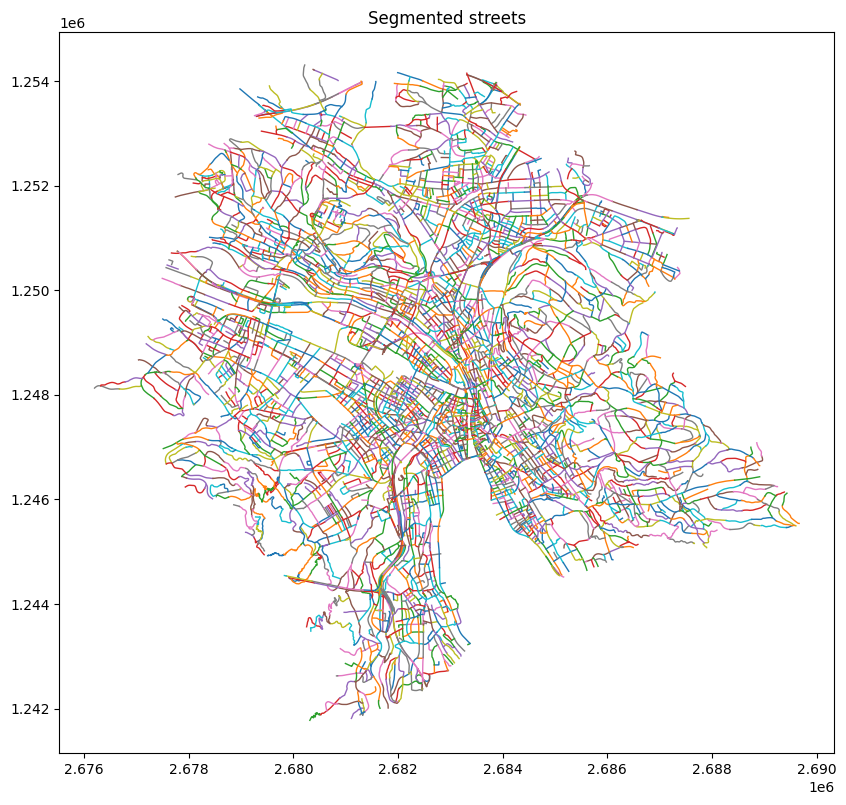

In [ ]:
# 0. Install & download
# Install required geospatial library
!pip install geopandas -q

# Download shapefile components (must all be present for GeoPandas to read)
!wget -q https://raw.githubusercontent.com/BeachBall2024/GEO-spa-algo/main/Streets_filtered_Zurich.shp
!wget -q https://raw.githubusercontent.com/BeachBall2024/GEO-spa-algo/main/Streets_filtered_Zurich.dbf
!wget -q https://raw.githubusercontent.com/BeachBall2024/GEO-spa-algo/main/Streets_filtered_Zurich.shx
!wget -q https://raw.githubusercontent.com/BeachBall2024/GEO-spa-algo/main/Streets_filtered_Zurich.prj

# 1. Imports
import geopandas as gpd        # For reading and handling geospatial data
import matplotlib.pyplot as plt  # For plotting
import pandas as pd           # For tabular data handling

# 2. Geometry helper classes
# for segmenting and interpolating along polylines.

class Point():
    """Simple 2D point"""
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def distanceTo(self, other):
        """Euclidean distance to another point"""
        return ((self.x - other.x)**2 + (self.y - other.y)**2) ** 0.5

    def toTuple(self):
        """Return (x, y) tuple (useful for plotting/storage)"""
        return (self.x, self.y)

class Polyline():
    """Represents a line made of multiple connected points"""
    def __init__(self, coords):
        # Convert coordinate tuples into Point objects
        self.points = [Point(x, y) for x, y in coords]

    def totalLength(self):
        """Compute total length of the polyline"""
        return sum(
            self.points[i].distanceTo(self.points[i+1])
            for i in range(len(self.points) - 1)
        )

    def interpolatePoint(self, dist):
        """
        Find a point at a given distance along the line.
        Useful for splitting segments precisely.
        """
        walked = 0.0

        for i in range(len(self.points) - 1):
            a = self.points[i]
            b = self.points[i + 1]
            edge = a.distanceTo(b)

            # Check if target distance lies on this segment
            if walked + edge >= dist:
                t = (dist - walked) / edge  # interpolation factor (0→1)
                return Point(
                    a.x + t * (b.x - a.x),
                    a.y + t * (b.y - a.y)
                )

            walked += edge

        # If distance exceeds total length, return last point
        return self.points[-1]

    def cutSegment(self, start, end):
        """
        Extract a sub-polyline between distances 'start' and 'end'
        """
        pts = [self.interpolatePoint(start)]
        walked = 0.0

        for i in range(len(self.points) - 1):
            a = self.points[i]
            b = self.points[i + 1]
            edge = a.distanceTo(b)
            mid = walked + edge

            # Include intermediate points if they lie inside the segment
            if mid > start and walked < end:
                if mid < end:
                    pts.append(b)

            walked += edge

            # Stop once we've reached the end distance
            if walked >= end:
                break

        pts.append(self.interpolatePoint(end))

        return Polyline([p.toTuple() for p in pts])

    def toCoords(self):
        """Return list of coordinate tuples"""
        return [p.toTuple() for p in self.points]

    def splitInto(self, max_len):
        """
        Split the polyline into smaller segments of max length 'max_len'
        Yields (segment_id, segment_polyline)
        """
        total = self.totalLength()
        start = 0.0
        seg_id = 0

        while start < total:
            end = min(start + max_len, total)

            yield seg_id, self.cutSegment(start, end)

            start += max_len
            seg_id += 1

# 3. Load shapefile & segment lines
NAME_COLUMN = 'STN_TEXT'  # Attribute column containing street name
MAX_LEN = 500             # Maximum segment length in meters

# Load shapefile into GeoDataFrame
gdf = gpd.read_file('Streets_filtered_Zurich.shp')
rows = []  # Will store all generated segments
uid = 0

# Iterate over each street feature
for _, row in gdf.iterrows():
    geom = row.geometry

    # Handle both LineString and MultiLineString geometries
    parts = list(geom.geoms) if geom.geom_type == 'MultiLineString' else [geom]

    # Process each individual line part
    for part in parts:
        polyline = Polyline(list(part.coords))

        # Split into smaller segments


        for seg_id, seg in polyline.splitInto(MAX_LEN):
            rows.append({
                'name': row[NAME_COLUMN],                 # street name
                'unique_id': uid,
                'seg_id': seg_id,                        # segment index
                'seg_len_m': round(seg.totalLength(), 2),# segment length
                'coords': seg.toCoords()                 # coordinates of segment
            })
            uid += 1

print(f"Created {len(rows)} segments")

# Convert to DataFrame for easier analysis/export
df = pd.DataFrame(rows)

# Display first 10 rows
print(df.head(10))

# 4. Plot segmented streets
fig, ax = plt.subplots(figsize=(10, 10))

# Plot each segment as a line
for r in rows:
    xs = [p[0] for p in r['coords']]
    ys = [p[1] for p in r['coords']]
    ax.plot(xs, ys, linewidth=1)

ax.set_title("Segmented streets")
ax.set_aspect('equal')  # Keep spatial proportions correct

plt.show()




In [ ]:
#Buffer implementation Muriel
import math
import matplotlib.pyplot as plt

#calculate normalised length vector
def direction_vector(p0, p1):
    dx = p1.x - p0.x
    dy = p1.y - p0.y
    length = math.sqrt(dx**2 + dy**2)

    #skip elements with length = 0
    if length == 0:
        ValueError("Segment hat Länge 0")
        pass

    #calculate unit vector
    nx = dx / length
    ny = dy / length

    #return norm. vector (length = 1)
    return nx, ny

def turn_test(p0, p1, p2):
    return (p1.x - p0.x)*(p2.y - p0.y) - (p1.y - p0.y)*(p2.x - p0.x)

#caclulate buffer around each street segment
def street_buffer(coord_points, width, num_circle_points=8):

    #ignoring segments with less than 2 points -> segment has to few points to create a buffer
    if len(coord_points) < 2:
        return []

    #calculate buffer radius
    r = width / 2
    left_side  = []
    right_side = []

    #loop going through each street segment
    for i in range(len(coord_points) - 1):

        #create Points out of the tuples of the list
        p0 = Point(coord_points[i][0],   coord_points[i][1])
        p1 = Point(coord_points[i+1][0], coord_points[i+1][1])
        dx, dy = direction_vector(p0, p1)
        nx, ny = -dy, dx


        #calculating start points
        if i == 0:
            left_side.append(Point(p0.x + nx*r, p0.y + ny*r))
            right_side.append(Point(p0.x - nx*r, p0.y - ny*r))

        #test if there is another point (we are not at the end of the line)
        if i < len(coord_points) - 2:
            #define p2 (Folgepunkt)
            p2 = Point(coord_points[i+2][0], coord_points[i+2][1])
            dx2, dy2 = direction_vector(p1, p2)
            nx2, ny2 = -dy2, dx2

            #do a turn test
            t = turn_test(p0, p1, p2)
            # t > 0 = left turn; t < 0 = right turn

            # Initialize arc_left and arc_right for each segment iteration
            arc_left = []
            arc_right = []
            steps = num_circle_points

            #calculate angles
            angle_in  = math.atan2(ny,  nx)
            angle_out = math.atan2(ny2, nx2)

            #create left arc
            if t > 0:
                diff = (angle_out - angle_in + math.pi) % (2*math.pi) - math.pi

                for j in range(steps + 1):
                    t_arc = j / steps # Use a different variable name to avoid confusion with the turn_test 't'
                    arc_angle = angle_in + diff * t_arc
                    arc_left.append(Point(p1.x + r * math.cos(arc_angle), p1.y + r * math.sin(arc_angle)))

                #add points to the list
                left_side.extend(arc_left)
                #append only 1 point on the other side
                right_side.append(Point(p1.x - nx*r, p1.y - ny*r))

            #create right arc
            elif t < 0: # Use elif to ensure only one arc is created for a turn
                #revers normal vector for different direction of arc
                angle_in_r  = math.atan2(-ny,  -nx)
                angle_out_r = math.atan2(-ny2, -nx2)
                diff_r = (angle_out_r - angle_in_r + math.pi) % (2*math.pi) - math.pi

                for j in range(steps + 1):
                    t_arc = j / steps # Use a different variable name
                    arc_angle = angle_in_r + diff_r * t_arc
                    arc_right.append(Point(p1.x + r * math.cos(arc_angle), p1.y + r * math.sin(arc_angle)))

                #add points to the list
                right_side.extend(arc_right)
                #append only 1 point on the other side
                left_side.append(Point(p1.x + nx*r, p1.y + ny*r))

            #no turn (t == 0)
            else:
                left_side.append(Point(p1.x + nx*r, p1.y + ny*r))
                right_side.append(Point(p1.x - nx*r, p1.y - ny*r))


            #add calculated rotational points to list
            left_side.extend(arc_left)
            right_side.extend(arc_right)

        # If it's the last segment, just add the buffer points for the end of the segment
        else: # This handles the case for the last segment where i < len(coord_points) - 2 is false
            left_side.append(Point(p1.x + nx*r, p1.y + ny*r))
            right_side.append(Point(p1.x - nx*r, p1.y - ny*r))

    #Semicircle at the start (around coord_points[0])
    #define start points (again)
    p0 = Point(coord_points[0][0], coord_points[0][1])
    dx0, dy0 = direction_vector(
        Point(coord_points[0][0], coord_points[0][1]),
        Point(coord_points[1][0], coord_points[1][1]))
    nx0, ny0 = -dy0, dx0
    start_cap = []

    #calculate points on rotation circle
    for i in range(num_circle_points):
        angle = math.pi + math.pi * i / (num_circle_points - 1)
        x = p0.x + r * (math.cos(angle) * nx0 + math.sin(angle) * dx0)
        y = p0.y + r * (math.cos(angle) * ny0 + math.sin(angle) * dy0)
        start_cap.append(Point(x, y))

    #Semicircle at the start (around coord_points[0])
    #define end points
    p_end = Point(coord_points[-1][0], coord_points[-1][1])
    dx_end, dy_end = direction_vector(
        Point(coord_points[-2][0], coord_points[-2][1]),
        Point(coord_points[-1][0], coord_points[-1][1]))
    nx_end, ny_end = -dy_end, dx_end

    end_cap = []

    #calculate points on rotation circle
    for i in range(num_circle_points):
        angle = math.pi * i / (num_circle_points - 1)
        x = p_end.x + r * (math.cos(angle) * nx_end + math.sin(angle) * dx_end)
        y = p_end.y + r * (math.cos(angle) * ny_end + math.sin(angle) * dy_end)
        end_cap.append(Point(x, y))

    #puzzle each segments togheter
    outline = left_side + end_cap + list(reversed(right_side)) + start_cap
    outline.append(outline[0])

    return outline

ZeroDivisionError: float division by zero

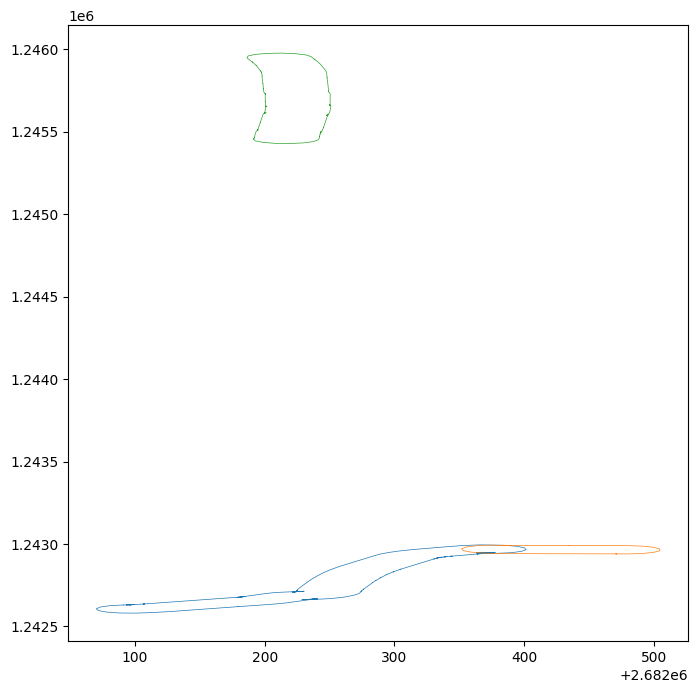

In [ ]:
#COMMANDS Buffer

#save results from segmentation in a more compact file
fig, ax = plt.subplots(figsize=(8, 8))

for _, row in df.iterrows():
    coord_points = row["coords"]
    outline = street_buffer(coord_points, width=50)

    xs = [p.x for p in outline]
    ys = [p.y for p in outline]
    ax.plot(xs, ys, '-', linewidth=0.5)


    """
    xs = [p.x for p in outline]
    ys = [p.y for p in outline]
    plt.figure()
    plt.plot(xs, ys, '-')
    plt.axis('equal')
    plt.title(f"Buffer {uid}")
    plt.show()
    """

ax.set_aspect('equal')
ax.set_title("All buffered street segments")
plt.tight_layout()
plt.show()

In [ ]:
#Print df
print(df.head(20))
print(type(df["coords"].iloc[0]))

                  name  unique_id  seg_id  seg_len_m  \
0            Dangelweg          0       0     500.00   
1            Dangelweg          1       1     103.70   
2   Waffenplatzstrasse          2       0     500.00   
3   Waffenplatzstrasse          3       1     297.55   
4        Buchenrainweg          4       0     500.00   
5        Buchenrainweg          5       1     213.47   
6        Buchenrainweg          6       0     288.90   
7        Buchenrainweg          7       0     124.59   
8        Buchenrainweg          8       0     500.00   
9        Buchenrainweg          9       1      69.27   
10        RÃ¤mistrasse         10       0      58.48   
11        RÃ¤mistrasse         11       0      13.57   
12        RÃ¤mistrasse         12       0      25.85   
13        RÃ¤mistrasse         13       0      81.11   
14        RÃ¤mistrasse         14       0      61.44   
15        RÃ¤mistrasse         15       0     390.08   
16        RÃ¤mistrasse         16       0      5

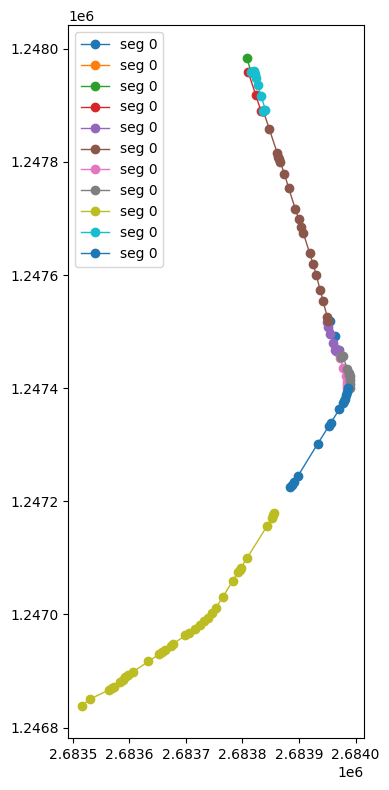

11
            name  seg_id                                             coords
10  RÃ¤mistrasse       0  [(2683968.8889999986, 1247467.1400000006), (26...
11  RÃ¤mistrasse       0  [(2683973.6290000007, 1247454.4290000014), (26...
12  RÃ¤mistrasse       0  [(2683815.0080000013, 1247959.7080000006), (26...
13  RÃ¤mistrasse       0  [(2683815.0080000013, 1247959.7080000006), (26...
14  RÃ¤mistrasse       0  [(2683952.0749999993, 1247518.4239999987), (26...
['Dangelweg' 'Waffenplatzstrasse' 'Buchenrainweg' 'RÃ¤mistrasse'
 'HÃ¼rlimannplatz' 'Schiffliwiesenweg' 'Bombachhalde' 'Chriesiweg'
 'Brombeeriweg' 'Geissbergweg' 'Zwirnerhalde' 'Kanzleistrasse'
 'Marktgasse' 'Torgasse' 'Allenmoosstrasse' 'Im Schellenberg'
 'Stadthausquai' 'Furttalstrasse' 'FÃ¼sslistrasse' 'Loorenkopfstrasse']


In [ ]:
#Plotting individual street segments
fig, ax = plt.subplots(figsize=(8, 8))

raemi = df[df["name"] == "RÃ¤mistrasse"]

for _, row in raemi.iterrows():
    coord_points = row["coords"]
    xs = [p[0] for p in coord_points]
    ys = [p[1] for p in coord_points]
    ax.plot(xs, ys, '-o', linewidth=1, label=f"seg {int(row['seg_id'])}")

ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.show()

print(len(raemi))
print(raemi[["name", "seg_id", "coords"]].head())
print(df["name"].unique()[:20])  # alle Strassennamen anzeigen


To DO's Muriel
1.   fusion 2 capsule elements
2.   calculate angles between 2 buffer capsules and only include relevant points
3.   Handling overlapping buffers



In [ ]:
import csv, math
from collections import defaultdict
from geo_proxy.shp_parser import read_shp
from geo_proxy.street_segmentation import (
    segment_streets, save_segments_csv, lv95_to_wgs84
)

# ── Settings ─────────────────────────────────────────────────────────
SHP_FILE   = 'streets_ZH.shp'
CSV_FILE   = 'amtliches-strassenverzeichnis_ch_2056.csv'
OUT_FILE   = 'data/zurich_street_segments.csv'
MAX_SEG_M  = 500
# ─────────────────────────────────────────────────────────────────────

# Run the full segmentation pipeline
street_segments = segment_streets(
    shp_path=SHP_FILE,
    csv_path=CSV_FILE,
    max_segment_length=MAX_SEG_M,
)

# Save to CSV for later use
save_segments_csv(street_segments, OUT_FILE)

# ── Summary statistics ───────────────────────────────────────────────
named = [s for s in street_segments if s['street_name'] != 'Unknown']
print(f'\nNamed segments: {len(named)} / {len(street_segments)}')

street_lengths = defaultdict(float)
for s in named:
    street_lengths[s['street_name']] += s['length_m']
top5 = sorted(street_lengths.items(), key=lambda x: -x[1])[:5]
print('\nTop 5 longest named streets:')
for name, length in top5:
    print(f'  {name}: {length:.0f} m')

print(f'\nSample segments:')
for s in named[:5]:
    print(f"  {s['street_name']:30s} seg {s['segment_id']}/{s['total_segments']}  "
          f"{s['length_m']:>7.1f}m  ({s['start_lat']}, {s['start_lon']})")

# 7. Creation of Buffer

**Task owner: Guillermo**

For each street segment, we construct a **rectangular buffer polygon** at a given distance (50 m default).
This is Algorithm 1 from our pipeline, implemented in `geo_proxy/algorithms.py`.

**Method (Lectures 1, 3):**
1. Compute the direction vector of the segment AB.
2. Rotate 90° to get the perpendicular unit vector.
3. Convert the buffer distance from metres to degrees using Haversine constants at the segment's mid-latitude (Lecture 1).
4. Offset both endpoints by ±perpendicular → four corners of a rectangle.

The resulting `Polygon` object carries a bounding box for fast spatial filtering (Lectures 3–4).

**Complexity:** O(1) per segment — constant number of geometric operations.

We also demonstrate `segments_intersect()` which uses four turn tests (cross products) with a
bounding-box pre-filter (Lecture 3) to detect overlapping buffer regions.

In [ ]:
from geo_proxy.primitives import Point, Segment, Polygon
from geo_proxy.algorithms import (
    build_segment_buffer, point_in_polygon, segments_intersect,
    SOUND_CATEGORIES
)

# ── Build Segment objects from our segmented streets ────────────────
# Use only named segments for the analysis
named_segments = [s for s in street_segments if s['street_name'] != 'Unknown']

# Create Segment primitives (lon = x, lat = y in WGS84)
seg_objects = []
seg_names   = []
for s in named_segments:
    p1 = Point(s['start_lon'], s['start_lat'])
    p2 = Point(s['end_lon'],   s['end_lat'])
    seg_objects.append(Segment(p1, p2))
    seg_names.append(s['street_name'])

print(f'Created {len(seg_objects)} Segment objects')

# ── Build buffer polygons (Algorithm 1) ───────────────────────────
BUFFER_DISTANCE = 50.0  # metres

buffers = []
for seg in seg_objects:
    buf = build_segment_buffer(seg, distance_m=BUFFER_DISTANCE)
    buffers.append(buf)

print(f'Built {len(buffers)} buffer polygons ({BUFFER_DISTANCE}m distance)')

# ── Demonstrate one buffer ────────────────────────────────────────
demo_idx = 0
demo_seg = seg_objects[demo_idx]
demo_buf = buffers[demo_idx]
print(f'\nDemo: {seg_names[demo_idx]}')
print(f'  Segment: ({demo_seg.p1.x:.6f}, {demo_seg.p1.y:.6f}) -> '
      f'({demo_seg.p2.x:.6f}, {demo_seg.p2.y:.6f})')
print(f'  Length: {demo_seg.length():.1f} m')
print(f'  Buffer vertices:')
for i, v in enumerate(demo_buf.vertices):
    print(f'    V{i}: ({v.x:.6f}, {v.y:.6f})')
centroid = demo_buf.calculate_centroid()
print(f'  Buffer centroid: ({centroid.x:.6f}, {centroid.y:.6f})')
print(f'  Buffer area: {demo_buf.calculate_area():.10f} sq degrees')

# ── Demonstrate segment intersection (Lecture 3 – turn test) ──────
if len(seg_objects) >= 2:
    cross = segments_intersect(seg_objects[0], seg_objects[1])
    print(f'\nSegments 0 and 1 intersect: {cross}')

# 8. Point-in-Polygon: Spatial Join & Sound Profile Computation

**Algorithm 2 (Lecture 4):** Ray-casting point-in-polygon with even-odd rule (Jordan Curve Theorem).
1. Bounding-box pre-filter (O(1)) rejects most non-candidate points.
2. Cast a horizontal ray from the test point to +∞.
3. Count intersections with polygon edges.
4. Odd count → point is inside.

**Algorithm 3:** Sound profile computation with z-score normalisation (Aiello et al., 2016).
- `sound(j,c) = tags(j,c) / tags(j)` — fraction per category per segment.
- `z(j,c) = (sound(j,c) - μ_c) / σ_c` — z-score normalisation for cross-category comparison.
- Dominant sound = category with highest z-score.

In [ ]:
from geo_proxy.pipeline import assign_sound_category, spatial_join, CATEGORY_WORD_SETS
from geo_proxy.algorithms import compute_sound_profile, zscore_normalise, dominant_sound
from geo_proxy.validation import parse_csv_points, parse_csv_noise, run_validation
from collections import Counter

# ── Load sound observation data ──────────────────────────────────
sound_points = parse_csv_points('data/zurich_sounds.csv')
print(f'Loaded {len(sound_points)} sound observation points')

# Show category distribution
cat_dist = Counter(p['sound_category'] for p in sound_points)
print('Category distribution:')
for cat, cnt in sorted(cat_dist.items(), key=lambda x: -x[1]):
    print(f'  {cat:12s}: {cnt:3d}')

# ── Run full spatial join pipeline (Algorithms 1+2+3) ────────────
print('\nRunning spatial join pipeline ...')
results = spatial_join(seg_objects, sound_points, buffer_distance=BUFFER_DISTANCE)
print(f'Processed {len(results)} street segments')

# ── Results summary ──────────────────────────────────────────────
sound_dist = Counter(r['dominant_sound'] for r in results)
print(f'\nDominant sound distribution:')
for cat, count in sorted(sound_dist.items(), key=lambda x: -x[1]):
    pct = count / len(results) * 100
    print(f'  {cat:12s}: {count:4d} segments ({pct:.1f}%)')

matched = [r for r in results if r['matched_points'] > 0]
print(f'\nSegments with >= 1 matched point: {len(matched)} / {len(results)}')
if matched:
    avg = sum(r['matched_points'] for r in matched) / len(matched)
    print(f'Average matched points per segment: {avg:.1f}')

# ── Validation against noise data ────────────────────────────────
noise_data = parse_csv_noise('data/zurich_noise.csv')
print(f'\nLoaded {len(noise_data)} noise measurement points')

val = run_validation(results, noise_data)
print(f'Spearman rank correlation (transport z-score vs dB):')
print(f'  rho = {val["spearman_rho"]:.4f}')
print(f'  n   = {val["n_matched_segments"]} matched segments')
print(f'  {val["interpretation"]}')

9. Visualization

In [ ]:
import matplotlib
matplotlib.use('Agg')  # non-interactive backend for Colab compatibility
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

COLOURS = {
    'transport':  '#e74c3c',
    'nature':     '#2ecc71',
    'human':      '#3498db',
    'music':      '#9b59b6',
    'mechanical': '#e67e22',
    'indoor':     '#95a5a6',
    'none':       '#ecf0f1',
}

# ── Plot 1: Sound map ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
for r in results:
    seg = r['segment']
    colour = COLOURS.get(r['dominant_sound'], '#cccccc')
    lw = 2.5 if r['matched_points'] > 0 else 0.4
    alpha = 0.9 if r['matched_points'] > 0 else 0.2
    ax.plot([seg.p1.x, seg.p2.x], [seg.p1.y, seg.p2.y],
            color=colour, linewidth=lw, alpha=alpha)

patches = [mpatches.Patch(color=c, label=cat)
           for cat, c in COLOURS.items() if cat != 'none']
ax.legend(handles=patches, loc='upper left', fontsize=9)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Chatty Maps Zürich – Dominant Sound per Street Segment')
plt.tight_layout()
plt.savefig('output_soundmap.png', dpi=150)
plt.show()
print('Sound map saved to output_soundmap.png')

# ── Plot 2: Buffer example ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
example = next((r for r in results if r['matched_points'] >= 2), results[0])
seg = example['segment']
buf = example['buffer']

verts = [(v.x, v.y) for v in buf.vertices] + [(buf.vertices[0].x, buf.vertices[0].y)]
xs, ys = zip(*verts)
ax.fill(xs, ys, alpha=0.2, color='blue', label=f'{BUFFER_DISTANCE}m buffer')
ax.plot(xs, ys, 'b--', linewidth=1)
ax.plot([seg.p1.x, seg.p2.x], [seg.p1.y, seg.p2.y],
        'b-', linewidth=3, label='Street segment')

for p in sound_points:
    if point_in_polygon(p['geometry'], buf):
        c = COLOURS.get(p['sound_category'], 'gray')
        ax.plot(p['geometry'].x, p['geometry'].y, 'o', color=c, markersize=8)

c = example['centroid']
ax.plot(c.x, c.y, 'kx', markersize=12, markeredgewidth=2, label='Centroid')
ax.legend(fontsize=8)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f"Buffer Example — Dominant: {example['dominant_sound']} "
             f"({example['matched_points']} points)")
plt.tight_layout()
plt.savefig('output_buffer_example.png', dpi=150)
plt.show()
print('Buffer example saved to output_buffer_example.png')